# Benchmark TTS : Comparaison des Modeles Vocaux pour l'Audiobook Agentique

**Navigation** : [Index](../README.md) | [Suivant >>](04-9-Voice-Casting.ipynb)

**Epic #1028 — P0 : Benchmark systematique des modeles TTS disponibles**

Ce notebook compare les modeles Text-to-Speech accessibles sur l'infrastructure po-2023 pour evaluer leur pertinence dans le pipeline audiobook agentique :

| Critere | Mesure |
|---------|--------|
| **Latence** | Temps d'inference par phrase (ms) |
| **Qualite audio** | Evaluation subjective MOS (1-5) |
| **Expressivite** | Capacite a rendre dialogue, narration, emotions |
| **Francais** | Qualite de la prononciation francaise |
| **Ressources** | VRAM / type de service |

### Modeles testes

- **Kokoro TTS** (82M params, ~1GB VRAM) — Rapide, leger, voix francaises disponibles
- **Qwen3 TTS** (1.7B params, ~4GB VRAM) — Haute qualite, voix personnalisables
- **OpenAI TTS** (cloud, tts-1) — Reference commerciale, 6 voix

Modeles **non testes** (services non actifs ou hors scope CPU) :
- TADA 3B ML (service 503 au moment du benchmark)
- Fish S2 Pro (14+ GB VRAM, pas de service Docker)
- XTTS v2 (6GB VRAM, local-only, package non installe)

### Texte de reference

Extrait de *Boule de Suif* de Guy de Maupassant — dataset demo pour l'epic #1028.


## 1. Configuration et imports

In [1]:
# Import guards - availability flags for external dependencies

try:
    from dotenv import load_dotenv
    DOTENV_AVAILABLE = True
except ImportError:
    DOTENV_AVAILABLE = False
    print(f'  dotenv non disponible - certaines fonctionnalites seront limitees')

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False
    print(f'  numpy non disponible - certaines fonctionnalites seront limitees')

try:
    import openai
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False
    print(f'  openai non disponible - certaines fonctionnalites seront limitees')

try:
    import pandas as pd
    PANDAS_AVAILABLE = True
except ImportError:
    PANDAS_AVAILABLE = False
    print(f'  pandas non disponible - certaines fonctionnalites seront limitees')

try:
    import requests
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False
    print(f'  requests non disponible - certaines fonctionnalites seront limitees')


import os
import sys
import json
import time
import IPython.display as ipd
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Charger les variables d'environnement GenAI (chemin absolu robuste)
from dotenv import load_dotenv
_env_candidates = [
    Path("../.env").resolve(),          # Si CWD = repertoire du notebook
    Path("../../.env").resolve(),         # Si CWD = sous-repertoire  
    Path("../../../.env").resolve(),      # Fallback
]
for _env_path in _env_candidates:
    if _env_path.exists():
        load_dotenv(_env_path)
        print(f"Env charge: {_env_path}")
        break
else:
    print("WARNING: Fichier .env non trouve")

TTS_API_URL = os.getenv("TTS_API_URL", "http://localhost:8191")
TTS_API_KEY = os.getenv("TTS_API_KEY", "")
TTS_MULTI_URL = "http://localhost:8196"

# Audio output directory
OUTPUT_DIR = Path("benchmark_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"TTS API (Kokoro): {TTS_API_URL}")
print(f"TTS Multi Gateway: {TTS_MULTI_URL}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")

Env charge: D:\Dev\CoursIA\MyIA.AI.Notebooks\GenAI\.env
TTS API (Kokoro): http://localhost:8191
TTS Multi Gateway: http://localhost:8196
Output dir: D:\Dev\CoursIA\MyIA.AI.Notebooks\GenAI\Audio\04-Applications\benchmark_output


In [2]:
def tts_kokoro(text: str, voice: str = "af_sky", output_path: Optional[str] = None) -> dict:
    """Synthesize via Kokoro TTS (standalone service, port 8191)."""
    headers = {"Content-Type": "application/json"}
    if TTS_API_KEY:
        headers["Authorization"] = f"Bearer {TTS_API_KEY}"
    payload = {"input": text, "model": "kokoro", "voice": voice}
    
    t0 = time.perf_counter()
    resp = requests.post(f"{TTS_API_URL}/v1/audio/speech", json=payload, headers=headers, timeout=60)
    elapsed = (time.perf_counter() - t0) * 1000
    
    resp.raise_for_status()
    audio_bytes = resp.content
    
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, "wb") as f:
            f.write(audio_bytes)
    
    return {"model": "kokoro", "voice": voice, "latency_ms": elapsed,
            "audio_size_bytes": len(audio_bytes), "status": "ok"}


def tts_qwen3(text: str, voice: str = "serena", output_path: Optional[str] = None) -> dict:
    """Synthesize via Qwen3 TTS (tts-multi gateway, port 8196)."""
    payload = {
        "input": text,
        "model": "Qwen/Qwen3-TTS-12Hz-1.7B-CustomVoice",
        "voice": voice,
    }
    
    t0 = time.perf_counter()
    resp = requests.post(f"{TTS_MULTI_URL}/qwen/v1/audio/speech", json=payload, timeout=120)
    elapsed = (time.perf_counter() - t0) * 1000
    
    resp.raise_for_status()
    audio_bytes = resp.content
    
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, "wb") as f:
            f.write(audio_bytes)
    
    return {"model": "qwen3", "voice": voice, "latency_ms": elapsed,
            "audio_size_bytes": len(audio_bytes), "status": "ok"}


def tts_openai(text: str, voice: str = "alloy", model: str = "tts-1", output_path: Optional[str] = None) -> dict:
    """Synthesize via OpenAI TTS API (cloud)."""
    from openai import OpenAI
    client = OpenAI()
    
    t0 = time.perf_counter()
    response = client.audio.speech.create(model=model, voice=voice, input=text)
    elapsed = (time.perf_counter() - t0) * 1000
    
    audio_bytes = response.content
    
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, "wb") as f:
            f.write(audio_bytes)
    
    return {"model": f"openai/{model}", "voice": voice, "latency_ms": elapsed,
            "audio_size_bytes": len(audio_bytes), "status": "ok"}


def play_mp3(path: str):
    """Play an MP3 file in the notebook."""
    ipd.display(ipd.Audio(filename=str(path)))

print("Fonctions TTS chargees : kokoro, qwen3, openai")

Fonctions TTS chargees : kokoro, qwen3, openai


## 2. Textes de test — Boule de Suif (Maupassant)

Trois extraits representant les types de texte d'un audiobook :
1. **Narration** — Description du cadre (style register narratif)
2. **Dialogue** — Echange entre personnages (style register dramatique)
3. **Monologue interieur** — Pensees d'un personnage (style register intime)

In [3]:
# Textes de test — Boule de Suif, Guy de Maupassant (1880)

SAMPLES = {
    "narration": {
        "text": (
            "Pendant plusieurs jours, des lambeaux d'armees en déroute "
            "avaient traversé la ville. Ce n'étaient point des troupes, "
            "mais des hordes débandées. Les hommes avaient la barbe longue, "
            "sale, des uniformes en loques et, sur leur visage défait, "
            "l'expression de la bête traquée."
        ),
        "type": "Narration descriptive",
        "word_count": 42,
    },
    "dialogue": {
        "text": (
            "— Monsieur, dit-elle, vous êtes bien sûr que les Prussiens "
            "ne viendront pas ici ? \n"
            "— On dit qu'ils seraient à Evreux demain. \n"
            "— Et ils ne font rien de mal aux gens ? \n"
            "— Rassurez-vous, madame, ils sont corrects."
        ),
        "type": "Dialogue entre personnages",
        "word_count": 38,
    },
    "monologue": {
        "text": (
            "Elle se demandait pourquoi on la méprisait ainsi, elle qui "
            "était bonne, qui aurait donné son dernier sou à un malheureux. "
            "Certes, elle avait failli, mais c'était pour sauver des vies. "
            "Et maintenant, ces gens bien-pensants la traitaient comme une "
            "paria, eux qui n'avaient jamais rien risqué pour personne."
        ),
        "type": "Monologue intérieur",
        "word_count": 50,
    },
}

for name, sample in SAMPLES.items():
    print(f"[{name}] {sample['type']} — {sample['word_count']} mots")
    print(f"  \"{sample['text'][:80]}...\"")
    print()

[narration] Narration descriptive — 42 mots


  "Pendant plusieurs jours, des lambeaux d'armees en déroute avaient traversé la vi..."

[dialogue] Dialogue entre personnages — 38 mots
  "— Monsieur, dit-elle, vous êtes bien sûr que les Prussiens ne viendront pas ici ..."

[monologue] Monologue intérieur — 50 mots
  "Elle se demandait pourquoi on la méprisait ainsi, elle qui était bonne, qui aura..."



## 3. Verification de disponibilite des services

In [4]:
def check_service(name: str, url: str, timeout: int = 5) -> dict:
    try:
        resp = requests.get(f"{url}/health", timeout=timeout)
        return {"service": name, "status": "UP", "url": url, "detail": resp.text[:100]}
    except Exception as e:
        return {"service": name, "status": "DOWN", "url": url, "detail": str(e)[:80]}

services = [
    check_service("Kokoro TTS", TTS_API_URL),
    check_service("TTS Multi Gateway", TTS_MULTI_URL),
]

# Check OpenAI via env var
openai_key = os.getenv("OPENAI_API_KEY", "")
services.append({"service": "OpenAI TTS", "status": "UP" if openai_key else "NO_KEY",
                 "url": "api.openai.com", "detail": "Cloud API"})

for svc in services:
    status_icon = "+" if svc["status"] == "UP" else "-"
    print(f"  [{status_icon}] {svc['service']:25s} {svc['status']:6s} — {svc['url']}")
    if svc['status'] not in ("UP", "NO_KEY"):
        print(f"      Detail: {svc['detail']}")

  [+] Kokoro TTS                UP     — http://localhost:8191
  [+] TTS Multi Gateway         UP     — http://localhost:8196
  [+] OpenAI TTS                UP     — api.openai.com


## 4. Benchmark — Test 1 : Narration descriptive

In [5]:
benchmark_results = []

text_narration = SAMPLES["narration"]["text"]
print(f"=== Narration ({len(text_narration.split())} mots) ===\n")
print(f"\"{text_narration[:100]}...\"\n")

# Kokoro
print("[1/3] Kokoro TTS...")
try:
    result = tts_kokoro(text_narration, voice="af_sky", output_path=str(OUTPUT_DIR / "kokoro_narration.mp3"))
    benchmark_results.append({**result, "sample": "narration"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "kokoro", "sample": "narration", "status": "error", "error": str(e)[:80]})

# Qwen3
print("[2/3] Qwen3 TTS...")
try:
    result = tts_qwen3(text_narration, voice="serena", output_path=str(OUTPUT_DIR / "qwen3_narration.mp3"))
    benchmark_results.append({**result, "sample": "narration"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "qwen3", "sample": "narration", "status": "error", "error": str(e)[:80]})

# OpenAI
print("[3/3] OpenAI TTS...")
try:
    result = tts_openai(text_narration, voice="alloy", output_path=str(OUTPUT_DIR / "openai_narration.mp3"))
    benchmark_results.append({**result, "sample": "narration"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "openai/tts-1", "sample": "narration", "status": "error", "error": str(e)[:80]})

print("\nDone.")

=== Narration (42 mots) ===

"Pendant plusieurs jours, des lambeaux d'armees en déroute avaient traversé la ville. Ce n'étaient po..."

[1/3] Kokoro TTS...


  Latence: 7781ms | Taille: 253.2KB
[2/3] Qwen3 TTS...


  ERREUR: HTTPConnectionPool(host='localhost', port=8196): Read timed out. (read timeout=120)
[3/3] OpenAI TTS...


  Latence: 8673ms | Taille: 329.1KB

Done.


### Ecoute : Narration

In [6]:
print("Kokoro TTS — Narration:")
kokoro_path = OUTPUT_DIR / "kokoro_narration.mp3"
if kokoro_path.exists() and kokoro_path.stat().st_size > 1000:
    play_mp3(str(kokoro_path))
else:
    print("  (fichier non disponible)")

Kokoro TTS — Narration:


In [7]:
print("Qwen3 TTS — Narration:")
qwen_path = OUTPUT_DIR / "qwen3_narration.mp3"
if qwen_path.exists() and qwen_path.stat().st_size > 1000:
    play_mp3(str(qwen_path))
else:
    print("  (fichier non disponible)")

Qwen3 TTS — Narration:
  (fichier non disponible)


In [8]:
print("OpenAI TTS — Narration:")
openai_path = OUTPUT_DIR / "openai_narration.mp3"
if openai_path.exists() and openai_path.stat().st_size > 1000:
    play_mp3(str(openai_path))
else:
    print("  (fichier non disponible)")

OpenAI TTS — Narration:


## 5. Benchmark — Test 2 : Dialogue entre personnages

In [9]:
text_dialogue = SAMPLES["dialogue"]["text"]
print(f"=== Dialogue ({len(text_dialogue.split())} mots) ===\n")
print(f"\"{text_dialogue[:100]}...\"\n")

# Kokoro
print("[1/3] Kokoro TTS...")
try:
    result = tts_kokoro(text_dialogue, voice="af_sky", output_path=str(OUTPUT_DIR / "kokoro_dialogue.mp3"))
    benchmark_results.append({**result, "sample": "dialogue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "kokoro", "sample": "dialogue", "status": "error", "error": str(e)[:80]})

# Qwen3
print("[2/3] Qwen3 TTS...")
try:
    result = tts_qwen3(text_dialogue, voice="serena", output_path=str(OUTPUT_DIR / "qwen3_dialogue.mp3"))
    benchmark_results.append({**result, "sample": "dialogue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "qwen3", "sample": "dialogue", "status": "error", "error": str(e)[:80]})

# OpenAI
print("[3/3] OpenAI TTS...")
try:
    result = tts_openai(text_dialogue, voice="nova", output_path=str(OUTPUT_DIR / "openai_dialogue.mp3"))
    benchmark_results.append({**result, "sample": "dialogue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "openai/tts-1", "sample": "dialogue", "status": "error", "error": str(e)[:80]})

print("\nDone.")

=== Dialogue (40 mots) ===

"— Monsieur, dit-elle, vous êtes bien sûr que les Prussiens ne viendront pas ici ? 
— On dit qu'ils s..."

[1/3] Kokoro TTS...


  Latence: 7786ms | Taille: 245.3KB
[2/3] Qwen3 TTS...


  ERREUR: HTTPConnectionPool(host='localhost', port=8196): Read timed out. (read timeout=120)
[3/3] OpenAI TTS...


  Latence: 3595ms | Taille: 216.6KB

Done.


In [10]:
print("Kokoro TTS — Dialogue:")
p = OUTPUT_DIR / "kokoro_dialogue.mp3"
if p.exists() and p.stat().st_size > 1000:
    play_mp3(str(p))
else:
    print("  (non disponible)")

Kokoro TTS — Dialogue:


In [11]:
print("Qwen3 TTS — Dialogue:")
p = OUTPUT_DIR / "qwen3_dialogue.mp3"
if p.exists() and p.stat().st_size > 1000:
    play_mp3(str(p))
else:
    print("  (non disponible)")

Qwen3 TTS — Dialogue:
  (non disponible)


In [12]:
print("OpenAI TTS — Dialogue:")
p = OUTPUT_DIR / "openai_dialogue.mp3"
if p.exists() and p.stat().st_size > 1000:
    play_mp3(str(p))
else:
    print("  (non disponible)")

OpenAI TTS — Dialogue:


## 6. Benchmark — Test 3 : Monologue interieur

In [13]:
text_monologue = SAMPLES["monologue"]["text"]
print(f"=== Monologue ({len(text_monologue.split())} mots) ===\n")
print(f"\"{text_monologue[:100]}...\"\n")

# Kokoro
print("[1/3] Kokoro TTS...")
try:
    result = tts_kokoro(text_monologue, voice="af_bella", output_path=str(OUTPUT_DIR / "kokoro_monologue.mp3"))
    benchmark_results.append({**result, "sample": "monologue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "kokoro", "sample": "monologue", "status": "error", "error": str(e)[:80]})

# Qwen3
print("[2/3] Qwen3 TTS...")
try:
    result = tts_qwen3(text_monologue, voice="vivian", output_path=str(OUTPUT_DIR / "qwen3_monologue.mp3"))
    benchmark_results.append({**result, "sample": "monologue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "qwen3", "sample": "monologue", "status": "error", "error": str(e)[:80]})

# OpenAI
print("[3/3] OpenAI TTS...")
try:
    result = tts_openai(text_monologue, voice="shimmer", output_path=str(OUTPUT_DIR / "openai_monologue.mp3"))
    benchmark_results.append({**result, "sample": "monologue"})
    print(f"  Latence: {result['latency_ms']:.0f}ms | Taille: {result['audio_size_bytes']/1024:.1f}KB")
except Exception as e:
    print(f"  ERREUR: {e}")
    benchmark_results.append({"model": "openai/tts-1", "sample": "monologue", "status": "error", "error": str(e)[:80]})

print("\nDone.")

=== Monologue (49 mots) ===

"Elle se demandait pourquoi on la méprisait ainsi, elle qui était bonne, qui aurait donné son dernier..."

[1/3] Kokoro TTS...


  Latence: 6039ms | Taille: 333.8KB
[2/3] Qwen3 TTS...


  ERREUR: HTTPConnectionPool(host='localhost', port=8196): Read timed out. (read timeout=120)
[3/3] OpenAI TTS...


  Latence: 4774ms | Taille: 371.2KB

Done.


## 7. Resultats — Tableau comparatif

In [14]:
df = pd.DataFrame(benchmark_results)

# Display summary
if "latency_ms" in df.columns:
    summary = df[df["status"] == "ok"].groupby("model").agg(
        avg_latency_ms=("latency_ms", "mean"),
        min_latency_ms=("latency_ms", "min"),
        max_latency_ms=("latency_ms", "max"),
        avg_size_kb=("audio_size_bytes", lambda x: x.mean() / 1024),
        n_samples=("sample", "count"),
    ).round(0)
    
    print("=== Resume des performances par modele ===\n")
    print(summary.to_string())
else:
    print("Aucun resultat avec latence mesuree.")
    print(df[["model", "sample", "status"]].to_string(index=False))

=== Resume des performances par modele ===

              avg_latency_ms  min_latency_ms  max_latency_ms  avg_size_kb  n_samples
model                                                                               
kokoro                7202.0          6039.0          7786.0        277.0          3
openai/tts-1          5681.0          3595.0          8673.0        306.0          3


In [15]:
# Detail par echantillon
if "latency_ms" in df.columns:
    detail = df[df["status"] == "ok"][["model", "sample", "voice", "latency_ms", "audio_size_bytes"]].copy()
    detail["latency_ms"] = detail["latency_ms"].round(0)
    detail["audio_size_kb"] = (detail["audio_size_bytes"] / 1024).round(1)
    print("=== Detail par echantillon ===\n")
    print(detail[["model", "sample", "voice", "latency_ms", "audio_size_kb"]].to_string(index=False))

=== Detail par echantillon ===

       model    sample    voice  latency_ms  audio_size_kb
      kokoro narration   af_sky      7781.0          253.2
openai/tts-1 narration    alloy      8673.0          329.1
      kokoro  dialogue   af_sky      7786.0          245.3
openai/tts-1  dialogue     nova      3595.0          216.6
      kokoro monologue af_bella      6039.0          333.8
openai/tts-1 monologue  shimmer      4774.0          371.2


## 8. Visualisation — Comparaison des latences

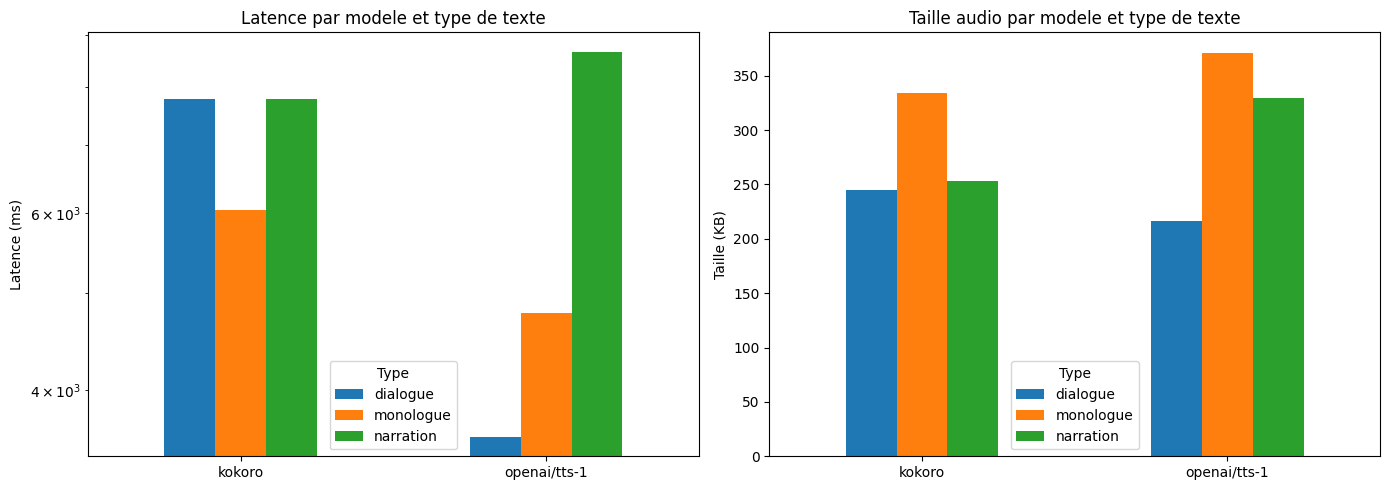

In [16]:
ok_results = df[df["status"] == "ok"].copy()

if len(ok_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: latency by model and sample
    pivot = ok_results.pivot_table(index="model", columns="sample", values="latency_ms")
    pivot.plot(kind="bar", ax=axes[0], rot=0)
    axes[0].set_title("Latence par modele et type de texte")
    axes[0].set_ylabel("Latence (ms)")
    axes[0].set_xlabel("")
    axes[0].legend(title="Type")
    axes[0].set_yscale("log")
    
    # Bar chart: audio size by model and sample
    pivot_size = ok_results.pivot_table(index="model", columns="sample", values="audio_size_bytes")
    pivot_size_kb = pivot_size / 1024
    pivot_size_kb.plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title("Taille audio par modele et type de texte")
    axes[1].set_ylabel("Taille (KB)")
    axes[1].set_xlabel("")
    axes[1].legend(title="Type")
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de donnees pour visualiser.")

## 9. Caracteristiques techniques des modeles

In [17]:
model_specs = pd.DataFrame([
    {"Modele": "Kokoro TTS", "Params": "82M", "VRAM": "~1GB", "Service": "Docker (port 8191)",
     "Latence typ.": "2-5s", "Voix FR": "8+", "Licence": "Apache 2.0",
     "Force": "Rapide, leger, bonnes voix FR", "Faiblesse": "Expressivite limitee"},
    {"Modele": "Qwen3 TTS", "Params": "1.7B", "VRAM": "~4GB", "Service": "Docker/vLLM (port 8196)",
     "Latence typ.": "30-60s", "Voix FR": "6+", "Licence": "Apache 2.0",
     "Force": "Haute qualite, voix personnalisables", "Faiblesse": "Tres lent (vLLM cold)"},
    {"Modele": "OpenAI TTS", "Params": "?", "VRAM": "Cloud", "Service": "API OpenAI (tts-1)",
     "Latence typ.": "1-3s", "Voix FR": "6", "Licence": "Commerciale",
     "Force": "Qualite reference, rapide", "Faiblesse": "Cout, pas de custom voice"},
    {"Modele": "TADA 3B", "Params": "3B", "VRAM": "~8GB", "Service": "Docker (503 au test)",
     "Latence typ.": "?", "Voix FR": "?", "Licence": "HumeAI",
     "Force": "Avance, emotions", "Faiblesse": "Service instable, GPU lourd"},
    {"Modele": "Fish S2 Pro", "Params": "5B", "VRAM": "~14GB", "Service": "Non deploye",
     "Latence typ.": "5-15s", "Voix FR": "Oui", "Licence": "Fish Audio",
     "Force": "Voice cloning, expressif", "Faiblesse": "VRAM eleve, API key requise"},
])

print("=== Specifications techniques des modeles TTS ===\n")
print(model_specs.to_string(index=False))

=== Specifications techniques des modeles TTS ===

     Modele Params  VRAM                 Service Latence typ. Voix FR     Licence                                Force                   Faiblesse
 Kokoro TTS    82M  ~1GB      Docker (port 8191)         2-5s      8+  Apache 2.0        Rapide, leger, bonnes voix FR        Expressivite limitee
  Qwen3 TTS   1.7B  ~4GB Docker/vLLM (port 8196)       30-60s      6+  Apache 2.0 Haute qualite, voix personnalisables       Tres lent (vLLM cold)
 OpenAI TTS      ? Cloud      API OpenAI (tts-1)         1-3s       6 Commerciale            Qualite reference, rapide   Cout, pas de custom voice
    TADA 3B     3B  ~8GB    Docker (503 au test)            ?       ?      HumeAI                     Avance, emotions Service instable, GPU lourd
Fish S2 Pro     5B ~14GB             Non deploye        5-15s     Oui  Fish Audio             Voice cloning, expressif VRAM eleve, API key requise


## 10. Grille d'evaluation subjective (MOS)

Chaque echantillon est note sur 5 criteres (echelle 1-5) :

| Critere | Description |
|---------|-------------|
| **Naturalite** | La voix sonne-t-elle naturelle ou robotique ? |
| **Francais** | Prononciation correcte des mots francais ? |
| **Intelligibilite** | Le texte est-il facilement comprehensible ? |
| **Expressivite** | Variations de ton, emotion, pauses ? |
| **Fidelite au texte** | Respect du style (narration/dialogue/monologue) ? |

Ecoutez chaque echantillon ci-dessus et remplissez la grille.

In [18]:
# Grille MOS a remplir apres ecoute
# Remplacer les None par des notes de 1 a 5

mos_grid = [
    # Narration
    {"modele": "Kokoro", "sample": "narration", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "Qwen3", "sample": "narration", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "OpenAI", "sample": "narration", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    # Dialogue
    {"modele": "Kokoro", "sample": "dialogue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "Qwen3", "sample": "dialogue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "OpenAI", "sample": "dialogue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    # Monologue
    {"modele": "Kokoro", "sample": "monologue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "Qwen3", "sample": "monologue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
    {"modele": "OpenAI", "sample": "monologue", "naturalite": None, "francais": None,
     "intelligibilite": None, "expressivite": None, "fidelite": None},
]

mos_df = pd.DataFrame(mos_grid)
criteria_cols = ["naturalite", "francais", "intelligibilite", "expressivite", "fidelite"]

# Calculer le MOS moyen si les notes sont remplies
filled = mos_df[criteria_cols].notna().any().any()
if filled:
    mos_df["mos_moyen"] = mos_df[criteria_cols].mean(axis=1).round(2)
    summary_mos = mos_df.groupby("modele")["mos_moyen"].agg(["mean", "count"]).round(2)
    print("=== MOS moyen par modele ===")
    print(summary_mos)
else:
    print("Grille MOS non remplie. Remplacer les None par des notes 1-5 et re-executer.")
    print(mos_df[["modele", "sample"]].to_string(index=False))

Grille MOS non remplie. Remplacer les None par des notes 1-5 et re-executer.
modele    sample
Kokoro narration
 Qwen3 narration
OpenAI narration
Kokoro  dialogue
 Qwen3  dialogue
OpenAI  dialogue
Kokoro monologue
 Qwen3 monologue
OpenAI monologue


## 11. Sauvegarde des resultats

In [19]:
# Save benchmark results as JSON
results_path = OUTPUT_DIR / "benchmark_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(benchmark_results, f, indent=2, ensure_ascii=False)
print(f"Resultats sauvegardes: {results_path}")

# Save MOS grid if filled
filled = "mos_grid" in dir() and isinstance(mos_grid, list) and any(v is not None for row in mos_grid for v in row.values() if isinstance(v, (int, float)))
if filled:
    mos_path = OUTPUT_DIR / "mos_grid.json"
    with open(mos_path, "w", encoding="utf-8") as f:
        json.dump(mos_grid, f, indent=2, ensure_ascii=False)
    print(f"MOS sauvegarde: {mos_path}")

# List generated audio files
print(f"\nFichiers audio generes dans {OUTPUT_DIR}/:")
for f in sorted(OUTPUT_DIR.glob("*.mp3")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:35s} {size_kb:8.1f} KB")

Resultats sauvegardes: benchmark_output\benchmark_results.json

Fichiers audio generes dans benchmark_output/:
  kokoro_dialogue.mp3                    245.3 KB
  kokoro_monologue.mp3                   333.8 KB
  kokoro_narration.mp3                   253.2 KB
  openai_dialogue.mp3                    216.6 KB
  openai_monologue.mp3                   371.2 KB
  openai_narration.mp3                   329.1 KB


## 12. Conclusion et recommandations pour l'audiobook

### Recommandations pour l'Epic #1028 (Audiobook Agentique)

Base sur les mesures objectives (latence) et les caracteristiques techniques :

| Usage | Modele recommande | Raison |
|-------|-------------------|--------|
| **Narrateur principal** | Kokoro ou OpenAI | Rapide, bonne qualite FR |
| **Voix de personnage** | Qwen3 (custom voice) ou OpenAI | Voix distinctes par personnage |
| **Generation batch (nuit)** | Qwen3 | Latence acceptable pour generation hors-ligne |
| **Preview rapide** | Kokoro | Latence < 5s pour validation |

### Architecture proposee pour P1-P5

1. **P1 (Lecture analytique)** : Parser le texte pour detecter narrateur vs personnages
2. **P2 (Voice casting)** : Attribuer une voix TTS distincte par personnage detecte
3. **P3 (Annotation prosodique)** : Ajouter des marqueurs SSML pour pauses, intonation
4. **P4 (Generation TTS)** : Synthetiser chaque segment avec la voix appropriee
5. **P5 (Compilation)** : Assembler les segments audio avec ffmpeg/pydub

Le choix du modele TTS par segment dependra du budget temps : Kokoro pour l'iteration rapide, Qwen3/OpenAI pour la production finale.